Core libraries imported.
Project directories ready.
Environment loaded. Model tiers:
  WEAK   -> gpt-4o-mini
  MID    -> gpt-5.4-mini
  STRONG -> gpt-5.4
Conditions: ['C1', 'C2', 'C3', 'C4', 'C5']
Datasets   : ['D1', 'D2', 'D2_fin', 'D3']
Grayscale plotting style configured.
Condition styles: {'C1': '0.15', 'C2': '0.3', 'C3': '0.45', 'C4': '0.6', 'C5': '0.75'}
Live check skipped (set RUN_LIVE_CHECK=True to test credentials).
Setup complete. Config snapshot saved.
Loaded full results: n=32598.


,dataset,model_tier,condition,n,EX,col_recall,col_precision,ctx_tokens,dEX_vs_C1
0,D1,MID,C1,1034,0.7573,0.9217,0.1562,418.4816,0.0000
1,D1,MID,C2,1034,0.7495,0.9206,0.1641,314.9410,-0.0077
2,D1,MID,C3,1034,0.7215,0.8743,0.1842,307.1103,-0.0358
3,D1,MID,C4,1034,0.7611,0.9212,0.1624,371.6925,0.0039
4,D1,STRONG,C1,1034,0.7785,0.9217,0.1562,418.4816,0.0000
5,D1,STRONG,C2,1034,0.7785,0.9206,0.1641,314.9410,0.0000
6,D1,STRONG,C3,1034,0.7427,0.8743,0.1842,307.1103,-0.0358
7,D1,STRONG,C4,1034,0.7776,0.9212,0.1624,371.6925,-0.0010
8,D1,WEAK,C1,1034,0.7466,0.9217,0.1562,418.4816,0.0000
9,D1,WEAK,C2,1034,0.7311,0.9206,0.1641,314.9410,-0.0155


Saved table: 08_ablation_table.csv, 08_ablation_table.tex
Saved figure: 08_ablation_signal.png, 08_ablation_signal.pdf


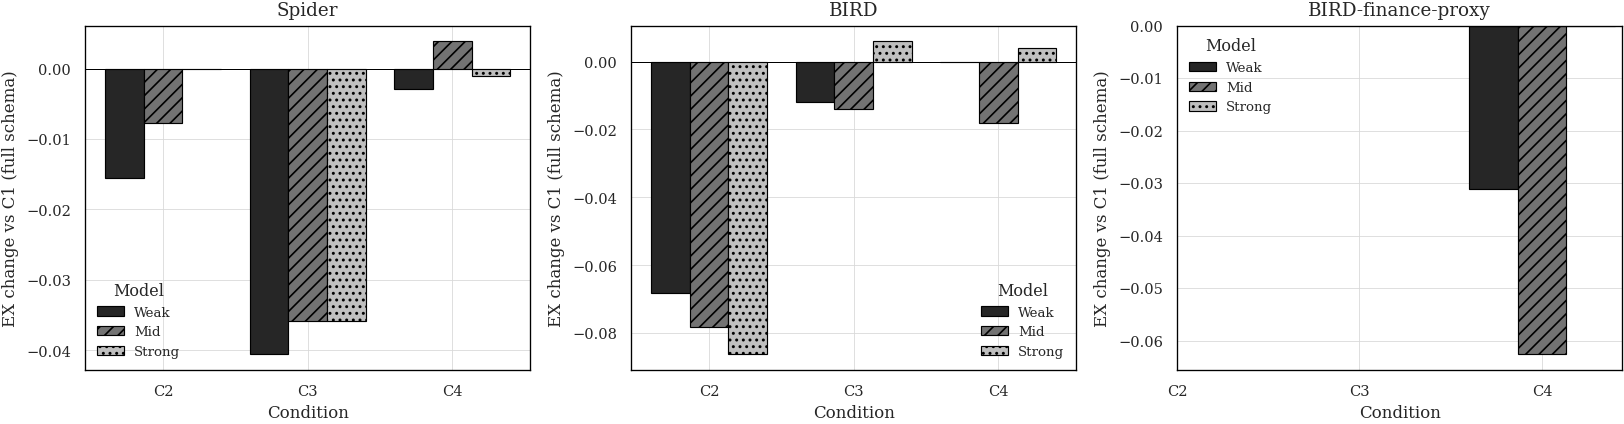

Saved figure: 08_savings_vs_ex_retention.png, 08_savings_vs_ex_retention.pdf


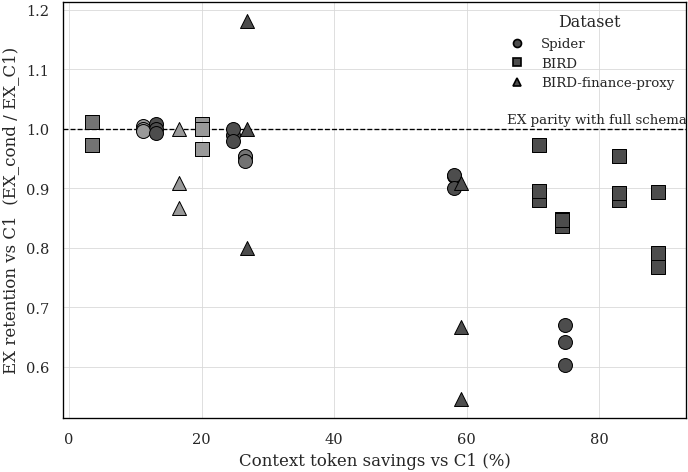

,dataset,model_tier,condition,savings_pct,ex_retention
0,D1,MID,C2,24.742,0.990
6,D1,STRONG,C2,24.742,1.000
12,D1,WEAK,C2,24.742,0.979
1,D1,MID,C3,26.613,0.953
7,D1,STRONG,C3,26.613,0.954
13,D1,WEAK,C3,26.613,0.946
2,D1,MID,C4,11.181,1.005
8,D1,STRONG,C4,11.181,0.999
14,D1,WEAK,C4,11.181,0.996
3,D1,MID,C5_L1,13.117,1.008


In [1]:
# ============================================================================
# 08_ablation.ipynb
# ----------------------------------------------------------------------------
# Beyond Full-Schema Prompting: A Graph-based Semantic Layer for Text-to-SQL
#
# Ablation + synthesis. Two parts:
#   (A) Condition ablation already in the data: C1 (full) vs C2 (vector) vs
#       C3 (graph) vs C4 (hybrid) - decomposes which retrieval signal helps.
#   (B) Cross-cutting synthesis figure for the reframed thesis: token savings vs
#       EX retention per condition/dataset, making explicit that only recall-
#       preserving conditions (small schema) keep EX while saving tokens.
#
# Consumes : results/tables/generation_results.csv
# Produces : 08_ablation_signal.{png,pdf}          C2 vs C3 vs C4 contribution
#            08_savings_vs_ex_retention.{png,pdf}   synthesis (safe vs unsafe)
#            08_ablation_table.{csv,tex}
#
# Anonymity: no filesystem paths are printed.
# ============================================================================


# %% [markdown]
# ## Cell 1 - Load configuration + results

# %%
%run 00_setup_and_config.ipynb


# %%
def load_results():
    full = TABLES_DIR / "generation_results.csv"
    if full.exists():
        df = pd.read_csv(full); print(f"Loaded full results: n={len(df)}.")
    else:
        raise FileNotFoundError("Run notebook 02 first.")
    return df

res = load_results()


# %% [markdown]
# ## Cell 2 - (A) Retrieval-signal ablation table
# Decomposes the retrieval signal: vector-only (C2), graph-only (C3), hybrid (C4),
# each vs the full-schema baseline (C1), per dataset x model.

# %%
ABLATION_CONDS = ["C1", "C2", "C3", "C4"]
ab = res[res["condition"].isin(ABLATION_CONDS)].dropna(subset=["exec_match"]).copy()

ab_table = (ab.groupby(["dataset", "model_tier", "condition"])
              .agg(n=("qid", "count"),
                   EX=("exec_match", "mean"),
                   col_recall=("col_recall_strict", "mean"),
                   col_precision=("col_precision_strict", "mean"),
                   ctx_tokens=("context_tokens_est", "mean"))
              .reset_index())

# delta EX vs C1 baseline
base = (ab_table[ab_table["condition"] == "C1"]
        .set_index(["dataset", "model_tier"])["EX"])
ab_table["dEX_vs_C1"] = ab_table.apply(
    lambda r: r["EX"] - base.get((r["dataset"], r["model_tier"]), np.nan), axis=1)
ab_table = ab_table.round(4).sort_values(["dataset", "model_tier", "condition"])
display(ab_table)
save_table(ab_table, "08_ablation_table")


# %% [markdown]
# ## Cell 3 - Figure: retrieval-signal contribution (dEX vs C1), grayscale
# Bars per condition (C2/C3/C4), grouped by model, one panel per dataset. Shows
# which single signal (vector vs graph) contributes, and whether hybrid combines
# them. Negative bars = worse than full schema (the D2 story).

# %%
def plot_signal_ablation(df):
    datasets = sorted(df["dataset"].unique())
    conds = ["C2", "C3", "C4"]
    fig, axes = plt.subplots(1, len(datasets),
                             figsize=(4.6 * len(datasets), 3.8), squeeze=False)
    for ax, ds in zip(axes[0], datasets):
        sub = df[df["dataset"] == ds]
        tiers = [t for t in MODEL_TIER_ORDER if t in sub["model_tier"].unique()]
        x = np.arange(len(conds)); w = 0.8 / max(1, len(tiers))
        for i, t in enumerate(tiers):
            vals = [sub[(sub["condition"] == c) & (sub["model_tier"] == t)]
                    ["dEX_vs_C1"].mean() for c in conds]
            bars = ax.bar(x + i * w, vals, width=w,
                          color=gray_palette(len(tiers))[i],
                          edgecolor="black", linewidth=0.7,
                          label=MODEL_TIER_LABELS.get(t, t))
            for b in bars:
                b.set_hatch(HATCHES[i % len(HATCHES)])
        ax.axhline(0, color="black", linewidth=0.6)
        ax.set_xticks(x + w * (len(tiers) - 1) / 2)
        ax.set_xticklabels(conds)
        ax.set_xlabel("Condition")
        ax.set_ylabel("EX change vs C1 (full schema)")
        ax.set_title(DATASETS.get(ds, ds))
        ax.legend(title="Model", fontsize=8)
    save_figure(fig, "08_ablation_signal")
    plt.show()

plot_signal_ablation(ab_table)


# %% [markdown]
# ## Cell 4 - (B) Synthesis: token savings vs EX retention
# The reframed-thesis figure. x = token savings vs C1 (%), y = EX retention vs C1
# (EX_cond / EX_C1). The safe zone is high-savings AND EX retention >= ~1.0.
# D1 conditions should sit near retention 1.0; D2 conditions fall below it,
# visually stating that savings are only safe when recall is preserved.

# %%
def synthesis_figure(df):
    d = df.dropna(subset=["exec_match"])
    cells = (d.groupby(["dataset", "model_tier", "condition"])
               .agg(EX=("exec_match", "mean"),
                    ctx=("context_tokens_est", "mean")).reset_index())
    # baselines per (dataset, model)
    base_ex = (cells[cells["condition"] == "C1"]
               .set_index(["dataset", "model_tier"])["EX"])
    base_ctx = (cells[cells["condition"] == "C1"]
                .set_index(["dataset", "model_tier"])["ctx"])
    rows = []
    for _, r in cells.iterrows():
        if r["condition"] == "C1":
            continue
        bx = base_ex.get((r["dataset"], r["model_tier"]), np.nan)
        bc = base_ctx.get((r["dataset"], r["model_tier"]), np.nan)
        rows.append({
            "dataset": r["dataset"], "model_tier": r["model_tier"],
            "condition": r["condition"],
            "savings_pct": 100 * (bc - r["ctx"]) / bc if bc else np.nan,
            "ex_retention": r["EX"] / bx if bx else np.nan,
        })
    syn = pd.DataFrame(rows)

    fig, ax = plt.subplots(figsize=(6.0, 4.2))
    ds_markers = {ds: MARKERS[i % len(MARKERS)]
                  for i, ds in enumerate(sorted(syn["dataset"].unique()))}
    for _, r in syn.iterrows():
        st = CONDITION_STYLE.get(r["condition"], {})
        ax.scatter(r["savings_pct"], r["ex_retention"],
                   s=70, marker=ds_markers.get(r["dataset"], "o"),
                   color=st.get("color", "0.3"),
                   edgecolor="black", linewidth=0.6, zorder=3)
    ax.axhline(1.0, color="black", linewidth=0.8, linestyle="--")
    ax.text(ax.get_xlim()[1], 1.005, "EX parity with full schema",
            ha="right", va="bottom", fontsize=8)
    ax.set_xlabel("Context token savings vs C1 (%)")
    ax.set_ylabel("EX retention vs C1  (EX_cond / EX_C1)")
    # dataset legend
    from matplotlib.lines import Line2D
    handles = [Line2D([0], [0], marker=m, color="0.3", linestyle="",
                      markeredgecolor="black", label=DATASETS.get(ds, ds))
               for ds, m in ds_markers.items()]
    ax.legend(handles=handles, title="Dataset", fontsize=8)
    save_figure(fig, "08_savings_vs_ex_retention")
    plt.show()
    return syn

synthesis = synthesis_figure(res)
display(synthesis.round(3).sort_values(["dataset", "condition", "model_tier"]))